In [58]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
%matplotlib inline
import matplotlib.pyplot as plt

# Fine-tune specific elements
plt.rcParams['font.size'] = 12          # Global default
plt.rcParams['axes.titlesize'] = 15     # Individual subplot titles
plt.rcParams['axes.labelsize'] = 15     # x and y labels
plt.rcParams['xtick.labelsize'] = 14    # x-axis tick numbers
plt.rcParams['ytick.labelsize'] = 14    # y-axis tick numbers
tick_fs = 14
plt.rcParams['legend.fontsize'] = 13    # Legend text
plt.rcParams['figure.titlesize'] = 16   # Figure suptitle

In [59]:
from matplotlib import ticker


def load_alpha_grid(filename):
        # Load the pre-calculated grid
    with open(filename, "rb") as f:
        alpha_grid = pickle.load(f)
    return alpha_grid

import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

def plot_precalculated_alpha(alpha_grid, k_values, k_in, k_out, min_log=-5, max_log=7, figname= None):
    # 1. Prepare data
    log_k = np.log10(k_values)
    mask = (log_k >= min_log) & (log_k <= max_log)
    
    # 2. Safe Log Calculation
    floor_val = -6.0
    log_alpha_grid = np.full_like(alpha_grid, floor_val)
    np.log10(alpha_grid, where=(alpha_grid > 0), out=log_alpha_grid)
    
    # 3. Plotting
    plt.figure(figsize=(4, 3))
    filtered_k = log_k[mask]
    extent = [filtered_k[0], filtered_k[-1], filtered_k[0], filtered_k[-1]]

    # 4. Colormap Customization
    current_cmap = plt.colormaps.get_cmap('plasma').copy()
    current_cmap.set_under('black') 
    current_cmap.set_bad('black') 
    
    vmin = floor_val + 0.1 
    vmax = np.max(log_alpha_grid) if np.max(log_alpha_grid) > vmin else vmin + 1
    
    im = plt.imshow(log_alpha_grid, origin='lower', extent=extent,
                    aspect='auto', cmap=current_cmap, vmin=vmin, vmax=vmax)

    # 5. Fixed Colorbar Logic
    # We use extend='min' so the colorbar shows the 'under' color (black)
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")
    cbar = plt.colorbar(im, extend='min', format=fmt)
    
    # Clear existing ticks to prevent duplicates
    # We define our own ticks: the floor_val for 0, and then standard intervals
    desired_ticks = np.arange(np.ceil(vmin), np.floor(vmax) + 1, 2)
    all_ticks = np.sort(np.append(desired_ticks, floor_val))
    
    cbar.set_ticks(all_ticks)
    
    # Create labels: floor_val becomes $0$, others use scientific notation
    labels = []
    for t in all_ticks:
        if t == floor_val:
            labels.append("$0$")
        else:
            labels.append(f"$10^{{{int(t)}}}$")
    
    cbar.set_ticklabels(labels)
    cbar.ax.tick_params(labelsize=tick_fs)
    cbar.set_label(r'Growth Rate ($\alpha$)', rotation=270, labelpad=20)
    
    # 6. Axes Formatting
    ax = plt.gca()
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    
    plt.axvline(x=0, color='lightblue', linestyle='--', alpha=0.7)
    plt.xlabel(fr'$k_{{{k_in}}}$')
    plt.ylabel(fr'$k_{{{k_out}}}$')
    plt.tick_params(axis='both', labelsize=tick_fs)
    if figname:
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [60]:
def plot_r2_map(r2_grid, k_values, k_in, k_out, min_log=-5, max_log=7, figname=None):
    """
    Plots the pre-calculated R^2 grid as a heatmap.
    """
    # 1. Axis preparation and slicing
    log_k = np.log10(k_values)
    mask = (log_k >= min_log) & (log_k <= max_log)
    
    filtered_grid = r2_grid[mask][:, mask]
    filtered_k = log_k[mask]
    
    if filtered_grid.size == 0:
        print("No data in range.")
        return
        
    # 2. Plotting
    plt.figure(figsize=( 4, 3))
    extent = [filtered_k[0], filtered_k[-1], filtered_k[0], filtered_k[-1]]
    
    # Using 'inferno' as in your original code; 'viridis' is also great for 0-1 scales
    im = plt.imshow(filtered_grid, origin='lower', extent=extent, 
                    aspect='auto', cmap='viridis', vmin=0, vmax=1)
    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=tick_fs)
    cbar.set_label(r'$R^2$ of the fit', rotation=270, labelpad=20)
    
    # 3. Format the Colorbar to 10^n
    # This formatter takes the log value and turns it into a LaTeX power of 10
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")
    
    ax = plt.gca()
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    
    plt.xlabel(fr'$k_{{{k_in}}}$')
    plt.ylabel(fr'$k_{{{k_out}}}$')
    plt.tick_params(axis='both')
    if figname:
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    
def get_data_for_specific_k(raw_data, k_values, target_k_in, target_k_out):
    # 1. Find the indices in your k_change array
    # We use np.isclose to avoid floating point precision issues
    try:
        idx_k1 = np.where(np.isclose(k_values, target_k_out))[0][0]
        idx_k2 = np.where(np.isclose(k_values, target_k_in))[0][0]
    except IndexError:
        print(f"Values k1={target_k_out} or k2={target_k_in} not found in k_values.")
        return None

    # 2. Calculate the flat index 'i' used in the pickle
    n = len(k_values)
    target_idx = (idx_k1 * n) + idx_k2
    
    # 3. Search for this index in your loaded data
    if target_idx in raw_data:
        return raw_data[target_idx] # Returns the list of replicates
        
    print(f"Index {target_idx} not found in the provided data.")
    return None
def get_k_values_from_indices(row, col, k_values):
    """
    Translates grid row and column indices into the actual k values.
    
    Parameters:
    row (int): The row index (corresponding to the outer loop/y-axis).
    col (int): The column index (corresponding to the inner loop/x-axis).
    k_values (array): The array of k values used (e.g., k_change).
    
    Returns:
    tuple: (k_value_y, k_value_x)
    """
    if row >= len(k_values) or col >= len(k_values):
        return "Index out of bounds", "Index out of bounds"
    
    k_y = k_values[row] # alto
    k_x = k_values[col] # bajo
    
    return k_y, k_x

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.io import savemat # Requires: pip install scipy

def plot_precalculated_alpha_3d(alpha_grid, k_values, k_in, k_out, min_log=-5, max_log=7):
    # Prepare grid and mask
    log_k = k_values 
    mask = (log_k >= min_log) & (log_k <= max_log)
    
    # Process Z data with floor
    floor_val = -6.0
    log_alpha_grid = np.full_like(alpha_grid, floor_val)
    np.log10(alpha_grid, where=(alpha_grid > 0), out=log_alpha_grid)
    
    filtered_grid = log_alpha_grid[mask][:, mask]
    filtered_k = log_k[mask]
    X, Y = np.meshgrid(filtered_k, filtered_k)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot surface
    surf = ax.plot_surface(X, Y, filtered_grid, cmap='plasma', 
                           linewidth=0, antialiased=True, alpha=0.9)

    # Formatting 10^n Labels
    fmt = ticker.FuncFormatter(lambda x, pos: f"$10^{{{int(x)}}}$")
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.zaxis.set_major_formatter(fmt)

    # FIX: Increased labelpad and manual figure adjustment
    ax.set_xlabel(fr'$k_{{{k_in}}}$', labelpad=15, fontsize=12)
    ax.set_ylabel(fr'$k_{{{k_out}}}$', labelpad=15, fontsize=12)
    ax.set_zlabel(r'Growth Rate ($\alpha$)', labelpad=15, fontsize=12)
    
    # Adjust the viewing angle to prevent labels from overlapping
    ax.view_init(elev=25, azim=-135) 

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, format=fmt)
    cbar.set_label(r'$\alpha$', rotation=0, labelpad=15)

    # Use tight_layout with padding to prevent label clipping
    plt.tight_layout(pad=3.0) 
    plt.show()

    # --- EXPORT TO MATLAB ---
    # We save the grid and the axis values into a .mat file
    mat_data = {
        "alpha_log_grid": filtered_grid,
        "k_log_values": filtered_k,
        "k_in_idx": k_in,
        "k_out_idx": k_out
    }
    savemat("growth_data_for_matlab.mat", mat_data)
    print("Data exported to 'growth_data_for_matlab.mat'")

# figuras

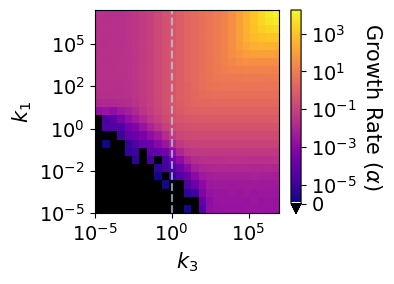

In [62]:
# Run the visualization
k2_vs_k4 = load_alpha_grid("alpha_sweep_k0_k2.pkl")
k_change = np.logspace(-5,7,25)

plot_precalculated_alpha(k2_vs_k4, k_change, k_in=3, k_out=1, figname="alpha_k1_vs_k3")


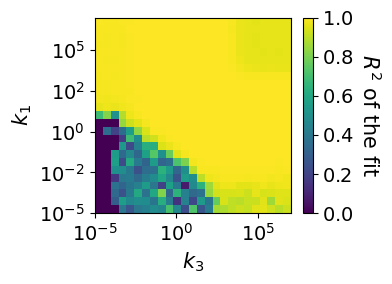

In [63]:
r2_grid = load_alpha_grid('r2_sweep_k0_k2.pkl')
plot_r2_map(r2_grid, k_change, 3,1, figname="r2_k1_vs_k3")

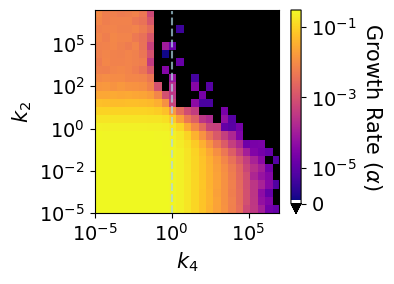

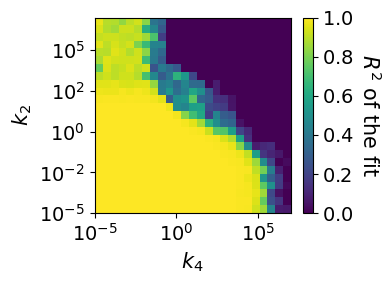

In [64]:
# Run the visualization
k2_vs_k4 = load_alpha_grid("alpha_sweep_k1_k3.pkl")
k_change = np.logspace(-5,7,25)

plot_precalculated_alpha(k2_vs_k4, k_change, k_in=4, k_out=2, figname="alpha_k2_vs_k4")


r2_grid = load_alpha_grid('r2_sweep_k1_k3.pkl')
plot_r2_map(r2_grid, k_change, 4, 2, figname="r2_k2_vs_k4")
